<a href="https://colab.research.google.com/github/NishkaArora/CN_recommendation_CS329H/blob/main/CS329H_Final_Project_Simulated_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1000 raters, 2000 notes

This is an approximation - we do not mimic the same sparsity pattern as the true notes data

In [1]:
N_USERS = 500
N_NOTES = 4000

# Sample 200 New Notes

NUM_CANDIDATE_NOTES = 300
T_steps = 40
FEED_LENGTH = 10
STRATEGIES = ['standard_ucb',
              'quality_threshold',
              'ideology_diversity_only',
              'ideology_quality',
              'ideology_quality_threshold']

TAU = 0.1 # note quality threshold for UCB-variants
p0 = 0.07 # starting probability
r = 0.7 # attention decay rate


# probabilities when users rate
HELPFUL_MIN = 0.6
NOT_HELPFUL_MAX = 0.45

# which notes are considered helpful according to their true values
H_THRESH = 0.5
NMR_THRESH = -0.2

LAMBDA_IDEOLOGY = 1
LAMBDA_QUALITY = 1
LAMBDA_EXP = 1

Generating data for 500 users and 4000 notes...
Generated sparse dataset with 100000 ratings.
Training Matrix Factorization Model...
Epoch 0: Loss = 0.1288
Epoch 10: Loss = 0.0670
Epoch 20: Loss = 0.0433
Epoch 30: Loss = 0.0356
Epoch 40: Loss = 0.0299
Epoch 50: Loss = 0.0255
Epoch 60: Loss = 0.0229
Epoch 70: Loss = 0.0215
Epoch 80: Loss = 0.0206
Epoch 90: Loss = 0.0200
Training complete.


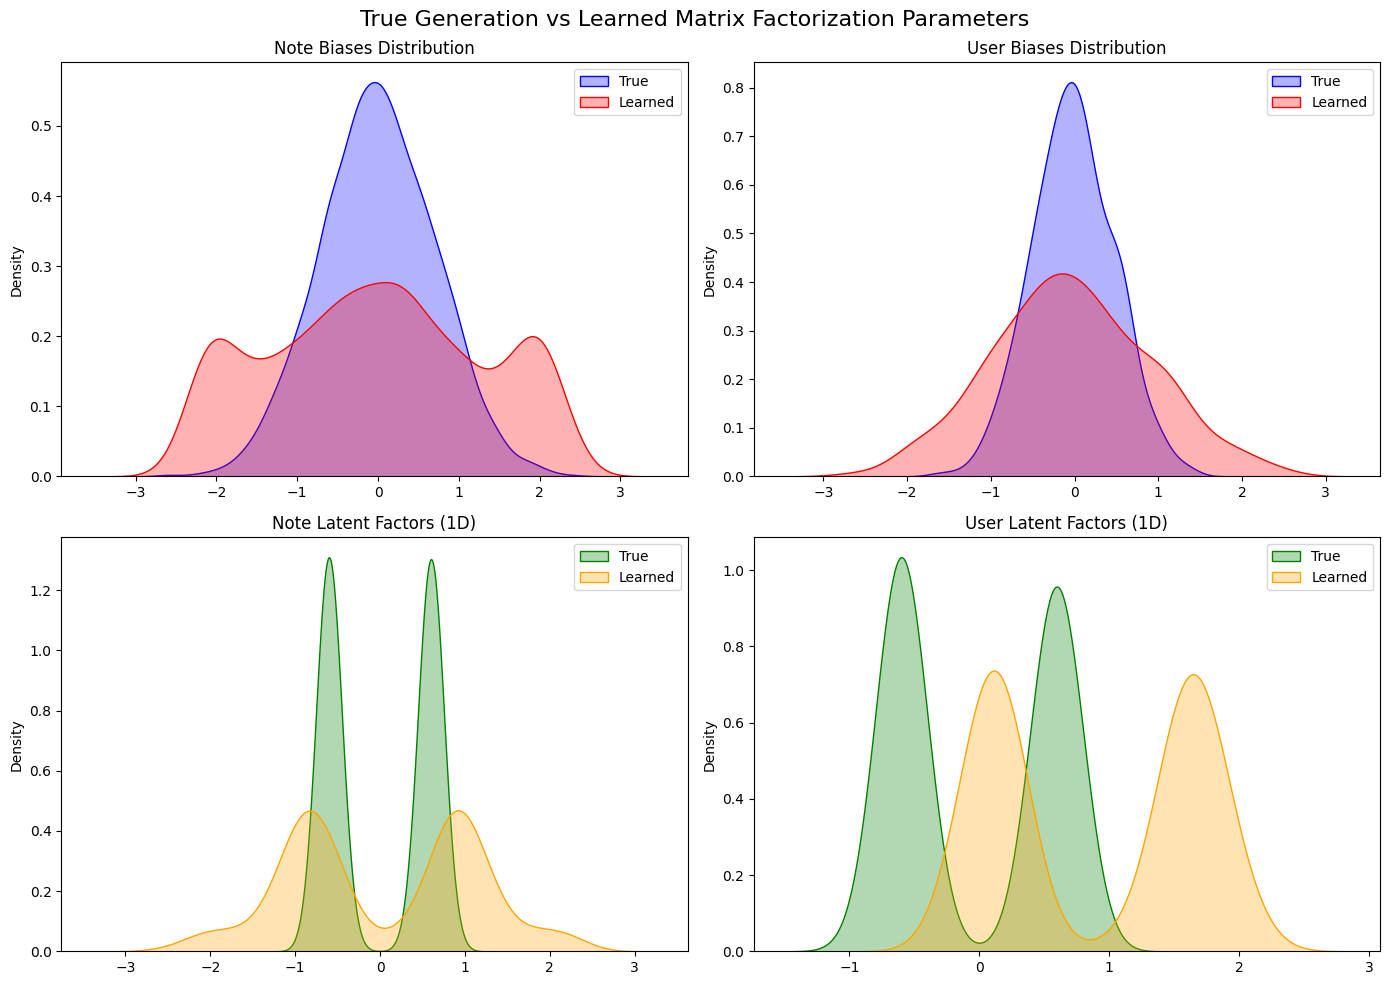


--- Data Access ---
Top 5 rows of sparse ratings matrix:
   user_id  note_id  rating  true_prob
0        3      446     0.5   0.544072
1      344      527     1.0   0.703702
2      227     3273     0.0   0.278219
3      180     2922     0.5   0.621570
4      430     1753     0.0   0.205238

Shape of Learned User Factors: (500,)


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

class CommunityNotesSim:
    def __init__(self, n_users=100, n_notes=400, latent_dim=1):
        self.n_users = n_users
        self.n_notes = n_notes
        self.latent_dim = latent_dim

        # Generated
        self.true_user_factors = None
        self.true_user_biases = None

        self.true_note_factors = None
        self.true_note_biases = None

        # to generate ratings matrix
        # score = user_factor \times note_factor + note_bias + user_bias
        # P(user u votes on note n) = sigmoid(score) > thresh -> helpful otherwise not helpful
        # user_factor, note_factor -> bimodal like CN data

        self.ratings_data = None # Sparse dataframe

        # Placeholders for model and learned params
        self.model = None # MF1D
        self.learned_user_factors = None
        self.learned_note_factors = None
        self.learned_user_biases = None
        self.learned_note_biases = None

        # Device config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def _sample_bimodal(self, n, focus1, focus2, noise_std=0.1):
        """Helper to sample from a mixture of two gaussians."""
        # Randomly choose which mode (focus) each sample belongs to
        modes = np.random.choice([focus1, focus2], size=n)
        # Add noise
        return modes + np.random.normal(0, noise_std, size=n)

    def generate_data(self, density=0.02):
        """
        Generates synthetic factors and sparse ratings.
        density: fraction of total possible ratings to observe (0.02 = 2%)
        """
        print(f"Generating data for {self.n_users} users and {self.n_notes} notes...")

        # 1. Generate True Parameters
        # Note factors (Bimodal -0.6, 0.6) & Biases (Normal 0, 0.7)
        self.true_note_factors = self._sample_bimodal(self.n_notes, -0.6, 0.6)
        self.true_note_biases = np.random.normal(0, 0.7, self.n_notes)

        # User factors (Bimodal -0.6, 0.6) & Biases (Normal 0, 0.5)
        self.true_user_factors = self._sample_bimodal(self.n_users, -0.6, 0.6)
        self.true_user_biases = np.random.normal(0, 0.5, self.n_users)

        # 2. Calculate Full Interaction Matrix (Vectorized)
        # Model: note_bias + user_bias + note_factor * user_factor
        # Broadcasting: (N,1) + (1,M) + (N,1)*(1,M)
        interaction = (
            self.true_note_biases[:, None] +
            self.true_user_biases[None, :] +
            (self.true_note_factors[:, None] * self.true_user_factors[None, :])
        )

        # 3. Apply Logistic Function
        probs = 1 / (1 + np.exp(-interaction))

        # 4. Create Sparse Sample (Masking)
        # Create a random mask for sparsity
        total_interactions = self.n_users * self.n_notes
        n_samples = int(total_interactions * density)

        # Get random indices
        note_indices = np.random.randint(0, self.n_notes, n_samples)
        user_indices = np.random.randint(0, self.n_users, n_samples)

        sampled_probs = probs[note_indices, user_indices]

        # 5. Thresholding for categories
        # Logic: < 0.35: Not Helpful (0.0), 0.35-0.65: Somewhat (0.5), > 0.65: Helpful (1.0)
        ratings = np.zeros_like(sampled_probs)
        ratings[sampled_probs >= 0.35] = 0.5
        ratings[sampled_probs >= 0.65] = 1.0

        # Store in a DataFrame for easy access
        self.ratings_data = pd.DataFrame({
            'user_id': user_indices,
            'note_id': note_indices,
            'rating': ratings,
            'true_prob': sampled_probs
        })
        print(f"Generated sparse dataset with {len(self.ratings_data)} ratings.")

    def train_matrix_factorization(self, epochs=50, lr=0.05):
        """Defines and trains the PyTorch model."""
        print("Training Matrix Factorization Model...")

        # --- Define Simple PyTorch Model ---
        class MatrixFactorization(nn.Module):
            def __init__(self, n_users, n_notes):
                super().__init__()
                self.user_factors = nn.Embedding(n_users, 1)
                self.note_factors = nn.Embedding(n_notes, 1)
                self.user_biases = nn.Embedding(n_users, 1)
                self.note_biases = nn.Embedding(n_notes, 1)

                # Init weights close to 0
                nn.init.xavier_uniform_(self.user_factors.weight)
                nn.init.xavier_uniform_(self.note_factors.weight)
                self.user_biases.weight.data.fill_(0.)
                self.note_biases.weight.data.fill_(0.)

            def forward(self, user, note):
                # Squeeze to remove the embedding dimension (N, 1) -> (N)
                mu = self.user_biases(user).squeeze()
                bi = self.note_biases(note).squeeze()
                pu = self.user_factors(user).squeeze()
                qi = self.note_factors(note).squeeze()

                # Prediction: bias + bias + dot_product
                return mu + bi + (pu * qi)

        # --- Prepare Data ---
        users = torch.LongTensor(self.ratings_data['user_id'].values).to(self.device)
        notes = torch.LongTensor(self.ratings_data['note_id'].values).to(self.device)
        ratings = torch.FloatTensor(self.ratings_data['rating'].values).to(self.device)

        # --- Setup Training ---
        self.model = MatrixFactorization(self.n_users, self.n_notes).to(self.device)
        criterion = nn.MSELoss() # Using MSE for simplicity on 0, 0.5, 1.0 targets
        optimizer = optim.Adam(self.model.parameters(), lr=lr)

        # --- Training Loop ---
        loss_history = []
        self.model.train()
        for epoch in range(epochs):
            optimizer.zero_grad()
            prediction_logits = self.model(users, notes)

            # Use Sigmoid on logits to match range [0,1]
            prediction_probs = torch.sigmoid(prediction_logits)

            loss = criterion(prediction_probs, ratings)
            loss.backward()
            optimizer.step()

            loss_history.append(loss.item())
            if epoch % 10 == 0:
                print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

        print("Training complete.")

        # --- Extract Learned Parameters ---
        self.model.eval()
        self.learned_user_factors = self.model.user_factors.weight.data.cpu().numpy().flatten()
        self.learned_note_factors = self.model.note_factors.weight.data.cpu().numpy().flatten()
        self.learned_user_biases = self.model.user_biases.weight.data.cpu().numpy().flatten()
        self.learned_note_biases = self.model.note_biases.weight.data.cpu().numpy().flatten()

    def plot_distributions(self):
        """Plots True vs Learned distributions."""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('True Generation vs Learned Matrix Factorization Parameters', fontsize=16)

        # 1. Note Biases
        sns.kdeplot(self.true_note_biases, ax=axes[0,0], label='True', fill=True, color='blue', alpha=0.3)
        sns.kdeplot(self.learned_note_biases, ax=axes[0,0], label='Learned', fill=True, color='red', alpha=0.3)
        axes[0,0].set_title('Note Biases Distribution')
        axes[0,0].legend()

        # 2. User Biases
        sns.kdeplot(self.true_user_biases, ax=axes[0,1], label='True', fill=True, color='blue', alpha=0.3)
        sns.kdeplot(self.learned_user_biases, ax=axes[0,1], label='Learned', fill=True, color='red', alpha=0.3)
        axes[0,1].set_title('User Biases Distribution')
        axes[0,1].legend()

        # 3. Note Factors (Should be bimodal)
        sns.kdeplot(self.true_note_factors, ax=axes[1,0], label='True', fill=True, color='green', alpha=0.3)
        sns.kdeplot(self.learned_note_factors, ax=axes[1,0], label='Learned', fill=True, color='orange', alpha=0.3)
        axes[1,0].set_title('Note Latent Factors (1D)')
        axes[1,0].legend()

        # 4. User Factors (Should be bimodal)
        sns.kdeplot(self.true_user_factors, ax=axes[1,1], label='True', fill=True, color='green', alpha=0.3)
        sns.kdeplot(self.learned_user_factors, ax=axes[1,1], label='Learned', fill=True, color='orange', alpha=0.3)
        axes[1,1].set_title('User Latent Factors (1D)')
        axes[1,1].legend()

        plt.tight_layout()
        plt.show()

    def compute_new_quality(self, ratings_history, l2_reg: float = 1e-3, eps: float = 1e-4):
        """
          Closed-form ridge regression to estimate (note_bias, note_factor) for a *single* note,
          given new ratings for that note and the already learned user parameters.
        """
        ratings = np.array([r[0] for r in ratings_history], dtype=float)
        user_ids = np.array([r[1] for r in ratings_history], dtype=int)

        user_biases = self.learned_user_biases[user_ids]
        user_factors = self.learned_user_factors[user_ids]

        y = ratings - user_biases
        X = np.column_stack([np.ones_like(user_factors), user_factors])

        XtX = X.T @ X
        XtX_reg = XtX + l2_reg * np.eye(2)
        Xty = X.T @ y

        beta = np.linalg.solve(XtX_reg, Xty)
        note_bias, note_factor = float(beta[0]), float(beta[1])
        return note_bias, note_factor

# --- Execution ---

# 1. Instantiate
sim = CommunityNotesSim(n_users=N_USERS, n_notes=N_NOTES)

# 2. Generate Data
# Note: "Very sparse" -> using 5% density here to ensure enough signal for training
sim.generate_data(density=0.05)

# 3. Train
sim.train_matrix_factorization(epochs=100, lr=0.05)

# 4. Visualize
sim.plot_distributions()

# 5. Access Data Example
print("\n--- Data Access ---")
print("Top 5 rows of sparse ratings matrix:")
print(sim.ratings_data.head())
print(f"\nShape of Learned User Factors: {sim.learned_user_factors.shape}")

In [3]:
class CandidateNote():
  def __init__(self, id, true_note_status = None):
    self.id = id

    if true_note_status is None:

      self.true_factor = CommunityNotesSim._sample_bimodal(None, 1, -0.6, 0.6)[0]
      self.true_bias = np.random.normal(0, 0.7, 1)[0]

      if self.true_bias > H_THRESH:
        self.true_note_status = 'H'
      elif self.true_bias > NMR_THRESH:
        self.true_note_status = 'NMR'
      else:
        self.true_note_status = 'NH'

    else:
      temp_true_bias = 0
      if true_note_status == 'H':
        self.true_note_status = 'H'
        while temp_true_bias <= H_THRESH:
          temp_true_bias = np.random.normal(0, 0.7, 1)[0]

      elif true_note_status == 'NMR':
        self.true_note_status = 'NMR'
        while temp_true_bias >= H_THRESH or temp_true_bias <= NMR_THRESH:
          temp_true_bias = np.random.normal(0, 0.7, 1)[0]

      elif true_note_status == 'NH':
        self.true_note_status = 'NH'
        while temp_true_bias > NMR_THRESH:
          temp_true_bias = np.random.normal(0, 0.7, 1)[0]

      self.true_bias = temp_true_bias
      self.true_factor = CommunityNotesSim._sample_bimodal(None, 1, -0.6, 0.6)[0]

    self.ratings_history = {}
    self.quality_history = {}
    self.curr_ucb_scores = {}

    self.learned_user_factor_history = {}

    # these use true user factor
    self.true_ideology_variance_history = {}
    self.true_user_factor_history = {}

    self.rerun = {} # whether to calculate note quality again

    for strategy in STRATEGIES:
      # for generating feeds
      self.curr_ucb_scores[strategy] = 0.0
      self.learned_user_factor_history[strategy] = []
      self.rerun[strategy] = False

      # mainly for logging
      self.ratings_history[strategy] = [] # every list item is a tuple (rating, user_id)
      self.quality_history[strategy] = [(0.0, 0)]

      self.true_user_factor_history[strategy] = []
      self.true_ideology_variance_history[strategy] = [0.0]

  def __str__(self):
    return f"CandidateNote(id={self.id}, true_factor={self.true_factor}, true_bias={self.true_bias})"

cnotes = []
for id in range(NUM_CANDIDATE_NOTES):
  cnotes.append(CandidateNote(id))

pd.Series([note.true_note_status for note in cnotes]).value_counts()

rated_matrix = np.zeros((N_USERS, NUM_CANDIDATE_NOTES), dtype=bool)

print(f"Initialized rated_matrix with shape: {rated_matrix.shape}")

# cnotes = []
# NUM_HELPFUL = math.floor(0.25*NUM_CANDIDATE_NOTES)
# NUM_NOT_HELPFUL = math.floor(0.25*NUM_CANDIDATE_NOTES)
# NUM_NMR = NUM_CANDIDATE_NOTES - NUM_HELPFUL - NUM_NOT_HELPFUL

# for id in range(NUM_HELPFUL):
#   cnotes.append(CandidateNote(id, true_note_status='H'))

# for id in range(NUM_HELPFUL, NUM_HELPFUL+NUM_NOT_HELPFUL):
#   cnotes.append(CandidateNote(id, true_note_status='NH'))

# for id in range(NUM_HELPFUL+NUM_NOT_HELPFUL, NUM_CANDIDATE_NOTES):
#   cnotes.append(CandidateNote(id, true_note_status='NMR'))

# assert len(cnotes) == NUM_CANDIDATE_NOTES, f"{NUM_CANDIDATE_NOTES} does not match length {len(cnotes)}"

Initialized rated_matrix with shape: (500, 300)


We don't sample for c_u, for simplicity, we assume identical users/raters in simulation -- may make this change later

In [4]:
import math
import random

def generate_feed_UCB(user_id, cnotes, cur_t,
                      STRATEGIES=STRATEGIES, FEED_LENGTH=FEED_LENGTH, TAU=TAU,
                      LAMBDA_IDEOLOGY=LAMBDA_IDEOLOGY, LAMBDA_QUALITY=LAMBDA_QUALITY, LAMBDA_EXP=LAMBDA_EXP):

  user_factor = sim.learned_user_factors[user_id] # ideology

  # notes the user hasn't already rated
  candidate_pool = [note for note in cnotes if not rated_matrix[user_id, note.id]]

  # If user has rated everything, return empty feeds or handle gracefully
  if not candidate_pool:
      print(f"User {user_id} has rated everything")
      return {s: [] for s in STRATEGIES}

  for cnote in candidate_pool:
    for strategy in STRATEGIES:

      n = len(cnote.learned_user_factor_history[strategy]) + 1.0
      exploration = LAMBDA_EXP * math.sqrt(2.0 * math.log(cur_t) / float(n))

      quality = LAMBDA_QUALITY * cnote.quality_history[strategy][-1][0]
      # quality_sigmoid = 1 / (1 + math.exp(-quality))

      # "note quality" and "note bias" in the matrix factorization
      # accounting for the new ratings

      quality_thresh = quality if quality > TAU else -TAU
      # assert (quality - quality_thresh) < 1e-4, f"quality: {quality}, quality_thresh: {quality_thresh}"

      if len(cnote.learned_user_factor_history[strategy]) > 0:
        ideology_variance = LAMBDA_IDEOLOGY * (1.0/n) * np.linalg.norm(cnote.learned_user_factor_history[strategy] - user_factor, 2)
      else:
        ideology_variance = 0.0

      if strategy == 'standard_ucb':
        cnote.curr_ucb_scores[strategy] = quality + exploration
      elif strategy == 'quality_threshold':
        cnote.curr_ucb_scores[strategy] = quality_thresh + exploration
      elif strategy == 'ideology_diversity_only':
        cnote.curr_ucb_scores[strategy] = ideology_variance + exploration
      elif strategy == 'ideology_quality':
        cnote.curr_ucb_scores[strategy] = quality + ideology_variance + exploration
      elif strategy == 'ideology_quality_threshold':
        cnote.curr_ucb_scores[strategy] = quality_thresh + ideology_variance + exploration
      else:
        raise ValueError(f"Unknown strategy: {strategy}")

  # random tie-breaking
  random.shuffle(candidate_pool)

  feeds = {}
  for strategy in STRATEGIES:
    sorted_notes = sorted(
            candidate_pool,
            key=lambda x: x.curr_ucb_scores[strategy],
            reverse=True
        )

    feeds[strategy] = sorted_notes[:min(FEED_LENGTH, len(candidate_pool))]
  return feeds

In [5]:
def simulate_ratings_from_feed(feed, user_id, strategy_name, cur_t,
                          p0=p0, r=r, HELPFUL_MIN=HELPFUL_MIN,
                          NOT_HELPFUL_MAX=NOT_HELPFUL_MAX):
  """
  Simulates a user scrolling through a feed and rating notes.
  Updates the CandidateNote objects in-place with new quality history.
  Accepts true user factor and user bias!
  """
  ratings_generated = []
  current_attention_p = p0
  true_user_factor = sim.true_user_factors[user_id]
  true_user_bias = sim.true_user_biases[user_id]

  for note in feed:

      if np.random.rand() > current_attention_p:
        # scrolled past
        current_attention_p *= r
        continue

      # If we are here, the user viewed the note.
      # Decay attention for the *next* note in the feed.
      current_attention_p *= r

      # Calculate Ground Truth Interaction
      true_note_factor = note.true_factor
      true_note_bias = note.true_bias

      # Dot product + biases
      raw_score = (true_user_factor * true_note_factor + true_user_bias + true_note_bias)
      # Sigmoid to get probability (0 to 1)
      prob_score = 1 / (1 + np.exp(-raw_score))

      # Determine Discrete Rating
      rating_val = 0.5 # Default: Somewhat Helpful

      if prob_score > HELPFUL_MIN:
          rating_val = 1.0 # Helpful
      elif prob_score < NOT_HELPFUL_MAX:
          rating_val = 0.0 # Not Helpful

      # Track the true user factor that provided this rating for logs/eval
      note.true_user_factor_history[strategy_name].append(true_user_factor)

      new_variance = np.var(note.true_user_factor_history[strategy_name])
      note.true_ideology_variance_history[strategy_name].append((new_variance, cur_t))

      # Update CandidateNote with new rating
      note.ratings_history[strategy_name].append((rating_val, user_id))
      note.rerun[strategy_name] = True
      rated_matrix[user_id, note.id] = True

In [6]:
# At each time step:
# For each user, generate a 5 feeds of length FEED_LENGTH each, get their ratings on the feed
# Calculate note quality history using regression approximation to matrix factorization
# The CommunityNotes class has the MF model.

import tqdm

for t in tqdm.tqdm(range(1, 1+T_steps)):

  # generate feeds and collect ratings from each user
  for user_id in range(sim.n_users):

    # feeds are generated using learned user factor
    feeds = generate_feed_UCB(user_id, cnotes, t)

    # ratings are collecting assuming true user factors
    for strategy in STRATEGIES:
      feed = feeds[strategy]
      simulate_ratings_from_feed(feed, user_id, strategy, t)

  if t % 1 == 0:
    for strategy in STRATEGIES:
      for note in cnotes:
        if note.rerun[strategy]:
          note.rerun[strategy] = False
          note_quality_est, _ = sim.compute_new_quality(note.ratings_history[strategy])
          note.quality_history[strategy].append((note_quality_est, t))

100%|██████████| 40/40 [00:32<00:00,  1.22it/s]


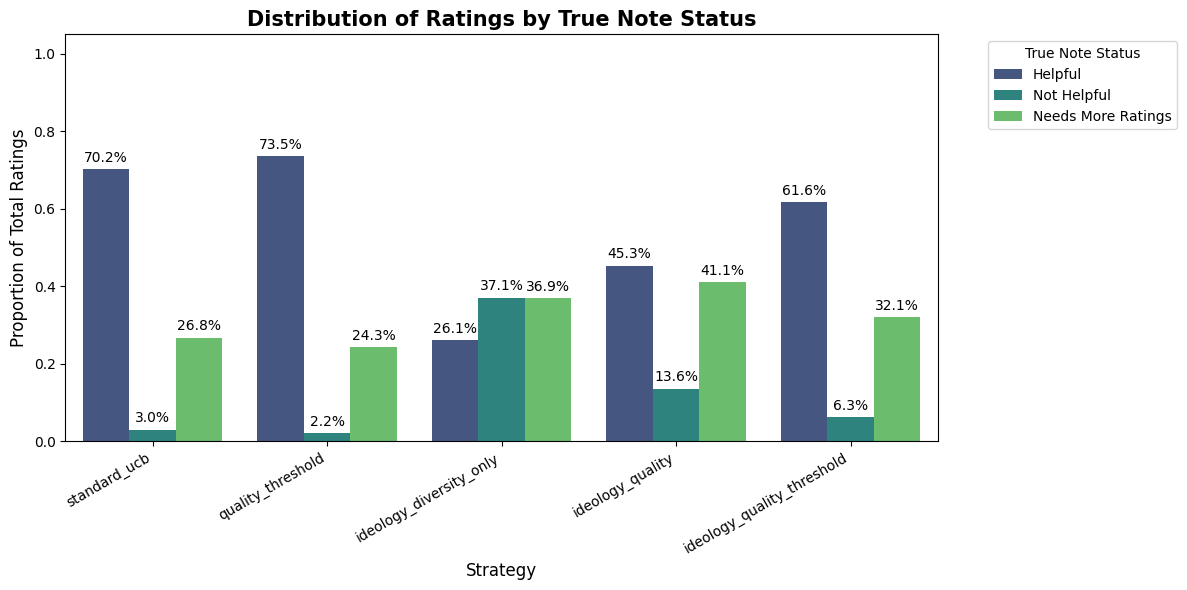

In [7]:
def plot_rating_distribution(cnotes, strategies=cnotes[0].curr_ucb_scores.keys()):
    """
    Plots the percentage of total ratings that went to Helpful, Not Helpful,
    and NMR (medium quality) notes for each strategy as a grouped bar chart.
    """
    data = []
    for strategy in strategies:
        counts = {'H': 0, 'NH': 0, 'NMR': 0}
        total_ratings = 0

        for note in cnotes:
            # Get note status (defaults to None if missing)
            status = getattr(note, 'true_note_status', None)

            # Check ratings for the specific strategy
            if strategy in note.ratings_history:
                num_ratings = len(note.ratings_history[strategy])

                if status in counts:
                    counts[status] += num_ratings
                    total_ratings += num_ratings

        # Calculate percentages and append to data list
        if total_ratings > 0:
            data.append({
                'Strategy': strategy,
                'Status': 'Helpful',
                'Percentage': counts['H'] / total_ratings
            })
            data.append({
                'Strategy': strategy,
                'Status': 'Not Helpful',
                'Percentage': counts['NH'] / total_ratings
            })
            data.append({
                'Strategy': strategy,
                'Status': 'Needs More Ratings',
                'Percentage': counts['NMR'] / total_ratings
            })

    # 2. Create DataFrame
    df = pd.DataFrame(data)

    if df.empty:
        print("No ratings data available to plot.")
        return

    # 3. Plotting
    plt.figure(figsize=(12, 6))

    # Create the bar plot with 'Strategy' on x-axis and 'Percentage' on y-axis
    # 'hue' separates the bars by 'Status'
    ax = sns.barplot(
        data=df,
        x='Strategy',
        y='Percentage',
        hue='Status',
        palette='viridis'
    )

    # Customization
    plt.title('Distribution of Ratings by True Note Status', fontsize=15, fontweight='bold')
    plt.xlabel('Strategy', fontsize=12)
    plt.ylabel('Proportion of Total Ratings', fontsize=12)
    plt.ylim(0, 1.05)  # Set y-axis limit to accommodate labels
    plt.xticks(rotation=30, ha='right') # Rotate x-labels for readability

    # Add percentage labels on top of each bar
    for container in ax.containers:
        # Create labels: multiply by 100 and add '%'
        labels = [f'{val*100:.1f}%' if not np.isnan(val) else '' for val in container.datavalues]
        ax.bar_label(container, labels=labels, padding=3, fontsize=10)

    # Move legend to a convenient spot
    plt.legend(title='True Note Status', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

# Example Usage:
plot_rating_distribution(cnotes)

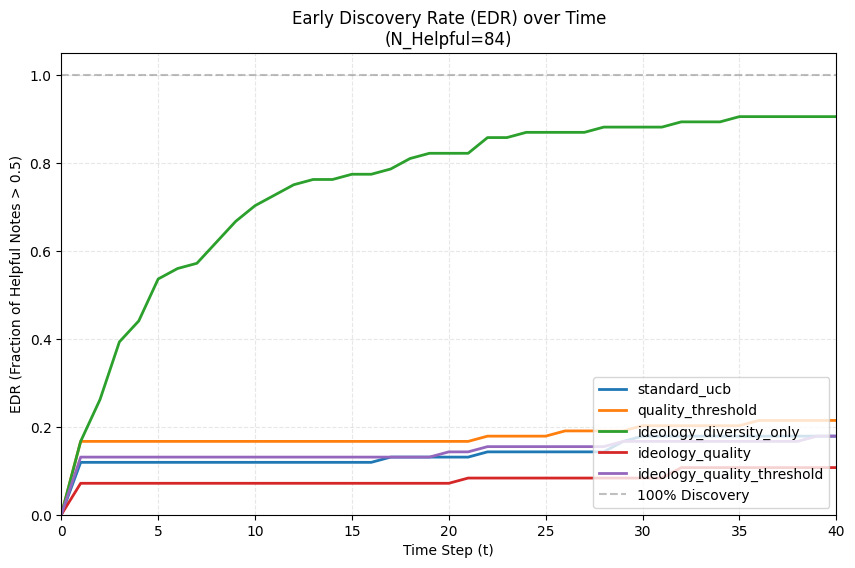

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def early_discovery_rate(cnotes, strategies, thresh=0.5, m=5):
    """
    Plots the Early Discovery Rate (EDR) over simulation time steps.

    EDR(W) = Fraction of helpful notes discovered by time W.
    Discovery is defined as having a quality estimate > thresh.

    Args:
    - cnotes: List of CandidateNote objects
    - strategies: List of strategy names
    - thresh: Quality threshold to be considered "discovered"
    - m: Minimum ratings (Implicitly handled by quality update existence)
    """

    # 1. Filter for Ground Truth Helpful Notes
    helpful_notes = [n for n in cnotes if n.true_note_status == 'H']
    total_helpful = len(helpful_notes)

    if total_helpful == 0:
        print("No helpful notes found in the dataset.")
        return

    # Find the maximum timestep reached in the simulation to set X-axis
    max_time = 0
    for note in cnotes:
        for strat in strategies:
            if note.quality_history[strat]:
                # quality_history is list of (score, t)
                last_t = note.quality_history[strat][-1][1]
                if last_t > max_time:
                    max_time = last_t

    # If simulation didn't run, default to 1 to avoid errors
    max_time = max(max_time, 1)

    plt.figure(figsize=(10, 6))

    # 2. Calculate EDR for each strategy
    for strategy in strategies:
        # List to store the time step 't' when each note was first discovered
        discovery_times = []

        for note in helpful_notes:
            # History is now [(q1, t1), (q2, t2), ...]
            history = note.quality_history[strategy]

            first_discovered_t = None

            # Iterate through history to find the *first* time it crossed the threshold
            for record in history:
                # Handle cases where history might be initialized with just floats or tuples
                if isinstance(record, tuple):
                    quality_est, t = record
                else:
                    # Fallback for initialization values like [0.0]
                    quality_est, t = record, 0

                if quality_est > thresh:
                    first_discovered_t = t
                    break

            if first_discovered_t is not None:
                discovery_times.append(first_discovered_t)

        # 3. Build the Cumulative EDR Curve over time W (0 to max_time)
        time_windows = range(max_time + 1)
        edr_curve = []

        for w in time_windows:
            # Count notes discovered at or before time w
            count_discovered = sum(1 for t in discovery_times if t <= w)
            fraction = count_discovered / total_helpful
            edr_curve.append(fraction)

        # 4. Plot
        plt.plot(time_windows, edr_curve, label=strategy, linewidth=2)

    # Styling
    plt.axhline(y=1.0, color='grey', linestyle='--', alpha=0.5, label="100% Discovery")
    plt.xlabel("Time Step (t)")
    plt.ylabel(f"EDR (Fraction of Helpful Notes > {thresh})")
    plt.title(f"Early Discovery Rate (EDR) over Time\n(N_Helpful={total_helpful})")
    plt.legend(loc='lower right')
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.ylim(0, 1.05)
    plt.xlim(0, max_time)
    plt.show()

# --- Execute Plotting ---
early_discovery_rate(cnotes, STRATEGIES, thresh=0.5)

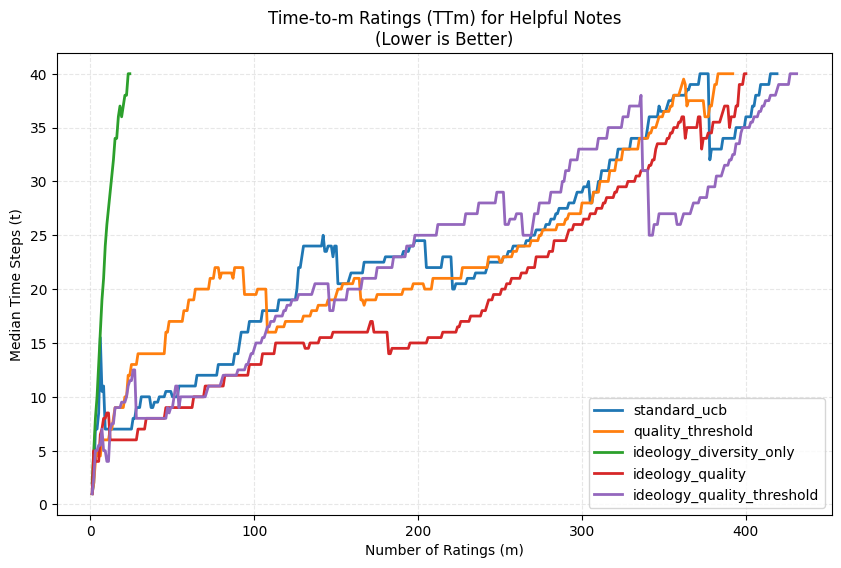

In [10]:
def plot_time_to_m_ratings(cnotes, strategies):
    """
    Plots the Time-to-m Ratings (TTm) curve.

    X-axis: Number of Ratings (m)
    Y-axis: Median Time Steps to reach m ratings
    """

    # 1. Filter for Ground Truth Helpful Notes
    helpful_notes = [n for n in cnotes if n.true_note_status == 'H']

    if not helpful_notes:
        print("No helpful notes found.")
        return

    # 2. Determine the range for X-axis (Max ratings received by any helpful note)
    max_ratings_found = 0
    for note in helpful_notes:
        for strat in strategies:
            # History length - 1 (because index 0 is initialization)
            count = len(note.true_ideology_variance_history.get(strat, [])) - 1
            if count > max_ratings_found:
                max_ratings_found = count

    # If simulation was short, default to a small range
    if max_ratings_found == 0:
        max_ratings_found = 10

    # Define m values to plot (1 up to max found)
    m_values = range(1, max_ratings_found + 1)

    plt.figure(figsize=(10, 6))

    for strategy in strategies:
        median_times = []
        valid_ms = []

        for m in m_values:
            times_to_reach_m = []

            for note in helpful_notes:
                hist = note.true_ideology_variance_history.get(strategy, [])

                # Check if this note received at least m ratings
                # We need index m to exist. Index 0 is init, Index 1 is 1st rating...
                if len(hist) > m:
                    entry = hist[m]

                    # Handle the tuple (variance, time) stored during simulation
                    if isinstance(entry, tuple):
                        time_step = entry[1]
                        times_to_reach_m.append(time_step)

            # Calculate median only if we have data for this m
            if times_to_reach_m:
                median_val = np.median(times_to_reach_m)
                median_times.append(median_val)
                valid_ms.append(m)

        # 3. Plot curve for this strategy
        # Only plot if we have data points
        if valid_ms:
            plt.plot(valid_ms, median_times, label=strategy, linewidth=2)

    plt.xlabel("Number of Ratings (m)")
    plt.ylabel("Median Time Steps (t)")
    plt.title(f"Time-to-m Ratings (TTm) for Helpful Notes\n(Lower is Better)")
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.3)

    # Set integer ticks for X axis for clarity
    plt.locator_params(axis='x', integer=True)
    plt.show()

# --- Execute Plotting ---
plot_time_to_m_ratings(cnotes, STRATEGIES)

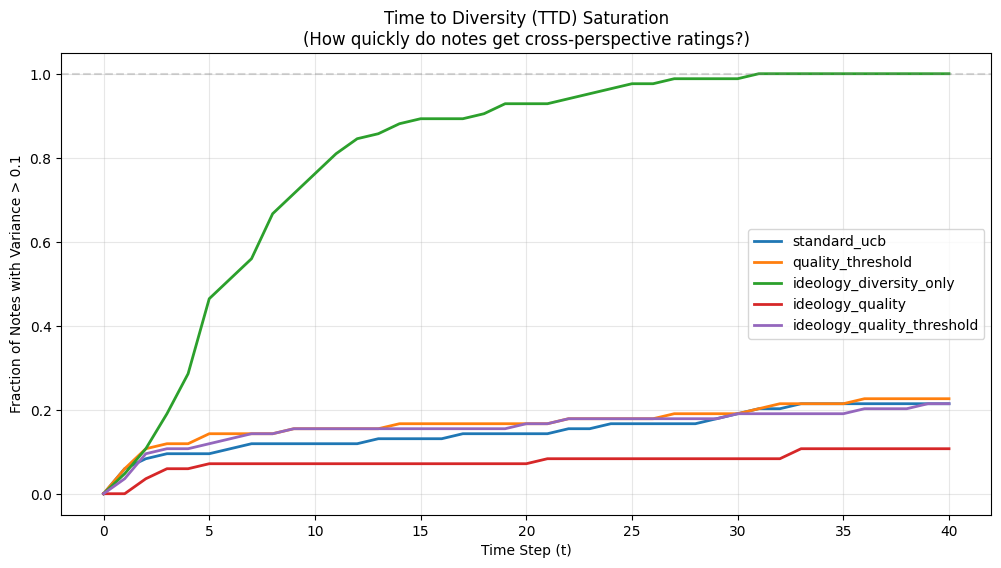

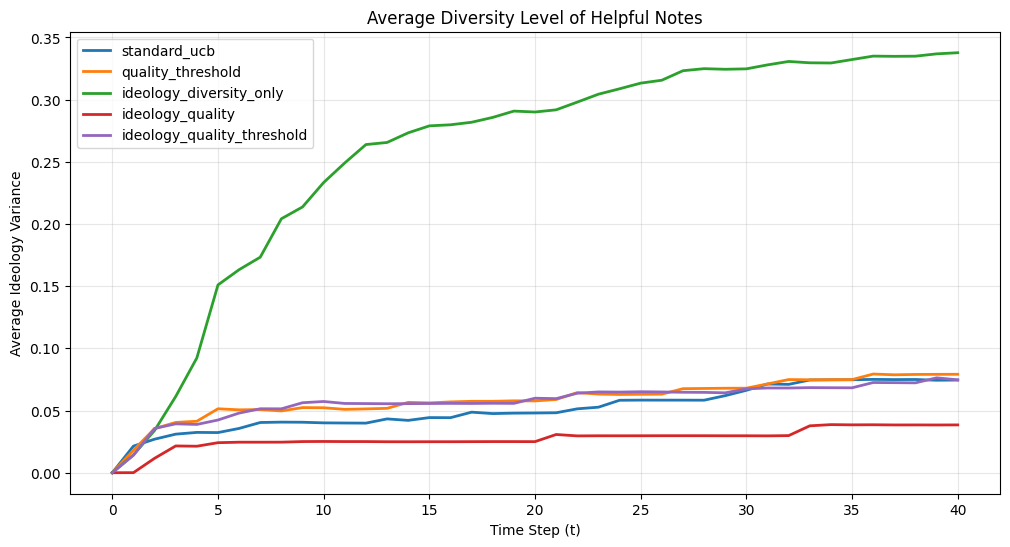

In [11]:
def plot_diversity_metrics(cnotes, strategies, var_thresh=0.1):
    """
    Plots diversity metrics to handle sparse data better than simple median.

    1. Diversity Saturation: % of Helpful notes with variance > var_thresh
    2. Mean Variance: Average variance of Helpful notes over time
    """

    # Filter for Ground Truth Helpful Notes
    helpful_notes = [n for n in cnotes if n.true_note_status == 'H']
    total_helpful = len(helpful_notes)

    if total_helpful == 0:
        print("No helpful notes found.")
        return

    # Determine max time
    max_time = 0
    for note in cnotes:
        for strat in strategies:
            hist = note.true_ideology_variance_history.get(strat, [])
            if hist and isinstance(hist[-1], tuple):
                max_time = max(max_time, hist[-1][1])

    max_time = max(max_time, 1)
    time_steps = range(max_time + 1)

    # --- Plot 1: Diversity Saturation (The TTD Curve) ---
    plt.figure(figsize=(12, 6))

    for strategy in strategies:
        saturation_curve = []

        for t in time_steps:
            # Count how many notes have crossed the variance threshold by time t
            count_diverse = 0

            for note in helpful_notes:
                hist = note.true_ideology_variance_history.get(strategy, [])

                # Get current variance at time t
                current_var = 0.0
                # Scan history efficiently (assuming sorted by t)
                for entry in reversed(hist):
                    # Handle (val, t) or default [0.0]
                    if isinstance(entry, tuple):
                        val, time_stamp = entry
                        if time_stamp <= t:
                            current_var = val
                            break
                    else:
                        # This catches the initialization 0.0
                        current_var = entry
                        break

                if current_var >= var_thresh:
                    count_diverse += 1

            saturation_curve.append(count_diverse / total_helpful)

        plt.plot(time_steps, saturation_curve, label=strategy, linewidth=2)

    plt.axhline(y=1.0, color='grey', linestyle='--', alpha=0.3)
    plt.xlabel("Time Step (t)")
    plt.ylabel(f"Fraction of Notes with Variance > {var_thresh}")
    plt.title(f"Time to Diversity (TTD) Saturation\n(How quickly do notes get cross-perspective ratings?)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- Plot 2: Average Diversity (Smoother than Median) ---
    plt.figure(figsize=(12, 6))

    for strategy in strategies:
        mean_variances = []

        for t in time_steps:
            variances_at_t = []

            for note in helpful_notes:
                hist = note.true_ideology_variance_history.get(strategy, [])

                current_var = 0.0
                for entry in reversed(hist):
                    if isinstance(entry, tuple):
                        val, time_stamp = entry
                        if time_stamp <= t:
                            current_var = val
                            break
                    else:
                        current_var = entry
                        break

                variances_at_t.append(current_var)

            # Use MEAN instead of MEDIAN to pick up signal in sparse data
            if variances_at_t:
                mean_variances.append(np.mean(variances_at_t))
            else:
                mean_variances.append(0.0)

        plt.plot(time_steps, mean_variances, label=strategy, linewidth=2)

    plt.xlabel("Time Step (t)")
    plt.ylabel("Average Ideology Variance")
    plt.title("Average Diversity Level of Helpful Notes")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- Execute ---
# Threshold 0.1 is reasonable given factors are roughly [-0.6, 0.6]
plot_diversity_metrics(cnotes, STRATEGIES, var_thresh=0.1)

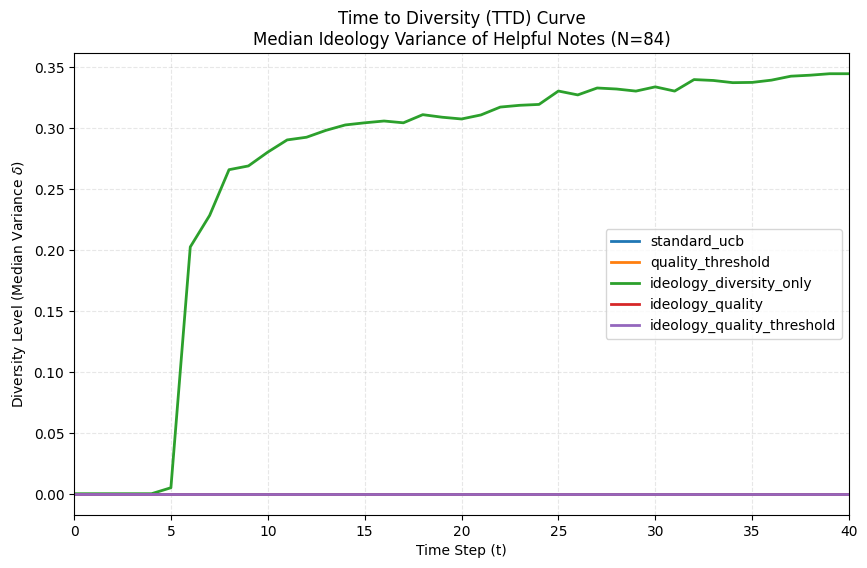

In [9]:
def plot_time_to_diversity(cnotes, strategies):
    """
    Plots the 'Time to Diversity' curve by showing the median rater ideology variance
    over time for Helpful notes.

    X-axis: Time Step (t)
    Y-axis: Variance level (delta)
    """

    # 1. Filter for Ground Truth Helpful Notes
    helpful_notes = [n for n in cnotes if n.true_note_status == 'H']

    if not helpful_notes:
        print("No helpful notes found.")
        return

    # 2. Determine simulation max time to set X-axis range
    max_time = 0
    for note in helpful_notes:
        for strat in strategies:
            hist = note.true_ideology_variance_history.get(strat, [])
            if hist:
                # Check the last entry to find the max timestep recorded
                last_entry = hist[-1]
                if isinstance(last_entry, tuple):
                    _, t_last = last_entry
                    if t_last > max_time:
                        max_time = t_last

    # Default to 1 if simulation didn't run to avoid range errors
    max_time = max(max_time, 1)

    plt.figure(figsize=(10, 6))

    # 3. Calculate curve for each strategy
    for strategy in strategies:
        median_variances = []
        time_steps = range(max_time + 1)

        for t in time_steps:
            variances_at_t = []

            # Collect the current variance for every helpful note at time t
            for note in helpful_notes:
                hist = note.true_ideology_variance_history.get(strategy, [])

                # Find the most recent variance calculated at or before time t
                current_var = 0.0 # Default

                # Iterate through history to find the latest applicable entry
                # (Note: Optimization possible if history is long, but linear scan is safe here)
                valid_vars = []
                for entry in hist:
                    # Handle mixed types: initial value is float 0.0, updates are (var, t)
                    if isinstance(entry, tuple):
                        val, time_stamp = entry
                    else:
                        val, time_stamp = entry, 0

                    if time_stamp <= t:
                        valid_vars.append(val)

                if valid_vars:
                    current_var = valid_vars[-1]

                variances_at_t.append(current_var)

            # Calculate median variance across notes for this timestep
            if variances_at_t:
                median_val = np.median(variances_at_t)
                median_variances.append(median_val)
            else:
                median_variances.append(0.0)

        # 4. Plot
        plt.plot(time_steps, median_variances, label=strategy, linewidth=2)

    plt.xlabel("Time Step (t)")
    plt.ylabel(r"Diversity Level (Median Variance $\delta$)")
    plt.title(f"Time to Diversity (TTD) Curve\nMedian Ideology Variance of Helpful Notes (N={len(helpful_notes)})")
    plt.legend()
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.xlim(0, max_time)
    plt.show()

# --- Execute Plotting ---
plot_time_to_diversity(cnotes, STRATEGIES)